# Detección de Objetos


In [2]:
import importlib
from ultralytics import YOLO
import supervision as sv
import cv2
import sys
sys.path.append("..")

from media_tools import video_tools as vt
from media_tools import image_tools as it
importlib.reload(vt)
importlib.reload(it)


<module 'media_tools.image_tools' from '/home/adrian/IA-Futbol/object_detection/../media_tools/image_tools.py'>

In [ ]:
#Entrenamiento del modelo 
DATA_PATH = "../dataset/object_detection/data.yaml" #Ruta al dataset
OUTPUT_PATH = "models" #Ruta donde se almacena el modelo entrenado

model = YOLO('models/train3/weights/best.pt')  #Modelo sin pesos
model.train(
    data=DATA_PATH,      
    epochs=5,
    imgsz=640,
    batch=4,
    device=0,
    project=OUTPUT_PATH         
)

In [18]:
model = YOLO('models/train4/weights/best.pt')
video_path = 'video_prueba.mp4'

In [ ]:
vt.write_video(video_path,output_path="video_prueba_BB.mp4",
               object_model=model,
               stylized_ob_detection=False,
               text_label=True)
vt.display_video("video_prueba_BB.mp4")

Processing: 100%|██████████| 1349/1349 [01:27<00:00, 15.47it/s]


In [19]:
vt.write_video(video_path,output_path="video_prueba_BB3_t4.mp4",
               object_model=model,
               stylized_ob_detection=True,
               text_label=True)
vt.display_video("video_prueba_BB3_t4.mp4")

Processing: 100%|██████████| 1349/1349 [00:44<00:00, 30.11it/s]


# Seguimiento de objetos (Tracking)

# Distinción de equipos

Se hará una distinción de los jugadores según al equipo al que pertenecen.




### Método 1

Recortar las imagenes de los jugadores a lo largo del partido y usar técnicas de clustering para agruparlos en 2 grupos


In [ ]:
model = YOLO('models/train3/weights/best.pt')
video_path = 'video_prueba.mp4'

crops = vt.extract_crops(video_path,model,ids=[1],crop_number=1000)

1013it [00:07, 142.31it/s]                         


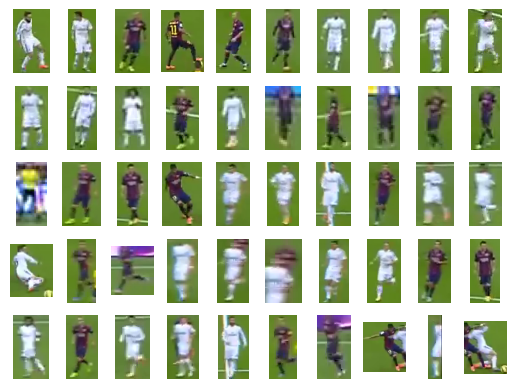

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5, 10)
number_crop = 0

for i in range(0,5):
    for j in range(0,10):

        axs[i,j].imshow(cv2.cvtColor(crops[number_crop], cv2.COLOR_BGR2RGB))
        axs[i,j].axis('off')
        number_crop +=1

        
plt.show()